# 成交价预测调试

这个 notebook 直接连接 `docker-compose` 里的 PostgreSQL，读取 `artworks` 数据，并用 XGBoost 训练一个成交价回归模型。默认标签来自 `extra_data.transactionPrice`。

In [1]:
from pathlib import Path
import sys

workspace_root = Path('/workspace')
if str(workspace_root / 'src') not in sys.path:
    sys.path.append(str(workspace_root / 'src'))

import matplotlib.pyplot as plt
import pandas as pd

from artfetch_ml.db import fetch_artwork_training_frame
from artfetch_ml.train import build_default_xgb_params, train_price_model
from artfetch_ml.viz import configure_matplotlib_for_chinese

pd.set_option('display.max_columns', 50)
selected_font = configure_matplotlib_for_chinese()
print('Matplotlib font:', selected_font or 'default fallback (no CJK font found)')

Matplotlib font: Noto Sans CJK JP


In [2]:
raw_df = fetch_artwork_training_frame(limit=5000)
raw_df.head()

,id,task_id,external_id,title,lot_number,artist,medium,format,dimensions,valuation,auction_house,auction_name,auction_session,auction_date,auction_location,preview_time,preview_location,extra_data,created_at
0,53990,3,art98320147,书法 镜心,0147,吴昌硕,水墨纸本,镜心,68×89cm,"50,000-60,000",东方国际,十五周年庆典2010年秋季“金融与收藏”拍卖会,中国书画,2010-12-18,北京赛特饭店多功能厅,2010年12月16日-17日,北京赛特饭店多功能厅（北京市朝阳区建国门外大街22号）,"{""transactionPrice"":""未提供"",""categoryLevel1"":""中国...",2026-04-18 05:16:10.831914
1,53989,3,art98320145,书法 横幅,0145,吴昌硕,水墨纸本,横幅,34×135cm,"8,000-10,000",东方国际,十五周年庆典2010年秋季“金融与收藏”拍卖会,中国书画,2010-12-18,北京赛特饭店多功能厅,2010年12月16日-17日,北京赛特饭店多功能厅（北京市朝阳区建国门外大街22号）,"{""transactionPrice"":""未提供"",""categoryLevel1"":""中国...",2026-04-18 05:16:10.831910
2,53988,3,art98320138,书法 镜心,0138,吴昌硕,水墨纸本,镜心,134×32cm×2,"6,000-8,000",东方国际,十五周年庆典2010年秋季“金融与收藏”拍卖会,中国书画,2010-12-18,北京赛特饭店多功能厅,2010年12月16日-17日,北京赛特饭店多功能厅（北京市朝阳区建国门外大街22号）,"{""transactionPrice"":""未提供"",""categoryLevel1"":""中国...",2026-04-18 05:16:10.831903
3,53987,3,art98590121,灵石图 立轴,0121,吴昌硕,水墨纸本,立轴,41×39cm,"1,000-2,000",北京恒丰,2010年恒丰之冬艺术品拍卖会,中国书画（一）,2010-12-18 上午9:00,北京朝阳区东三环南路100号船舶酒店三层宴会厅,2010年12月16日 上午9:00-下午19:30 2010年12月17日 上午9:00-...,北京朝阳区东三环南路100号船舶酒店,"{""transactionPrice"":""流拍"",""categoryLevel1"":""中国书...",2026-04-18 05:16:10.831897
4,53986,3,art98320112,1890年作 宋人诗意图 立轴,0112,吴昌硕,设色纸本,立轴,122×37cm,"4,000-6,000",东方国际,十五周年庆典2010年秋季“金融与收藏”拍卖会,中国书画,2010-12-18,北京赛特饭店多功能厅,2010年12月16日-17日,北京赛特饭店多功能厅（北京市朝阳区建国门外大街22号）,"{""creationEra"":""1890年作"",""transactionPrice"":""未提...",2026-04-18 05:16:10.831891


In [3]:
raw_df[['id', 'title', 'artist', 'valuation', 'extra_data']].head(10)

,id,title,artist,valuation,extra_data
0,53990,书法 镜心,吴昌硕,"50,000-60,000","{""transactionPrice"":""未提供"",""categoryLevel1"":""中国..."
1,53989,书法 横幅,吴昌硕,"8,000-10,000","{""transactionPrice"":""未提供"",""categoryLevel1"":""中国..."
2,53988,书法 镜心,吴昌硕,"6,000-8,000","{""transactionPrice"":""未提供"",""categoryLevel1"":""中国..."
3,53987,灵石图 立轴,吴昌硕,"1,000-2,000","{""transactionPrice"":""流拍"",""categoryLevel1"":""中国书..."
4,53986,1890年作 宋人诗意图 立轴,吴昌硕,"4,000-6,000","{""creationEra"":""1890年作"",""transactionPrice"":""未提..."
5,53985,1912年作 多子多福 立轴,吴昌硕,"16,000-18,000","{""creationEra"":""1912年作"",""transactionPrice"":""未提..."
6,53984,花卉 镜心,吴昌硕,无底价,"{""transactionPrice"":""未提供"",""categoryLevel1"":""中国..."
7,53983,花卉 立轴,吴昌硕,"80,000-120,000","{""transactionPrice"":""235,200"",""categoryLevel1""..."
8,53982,书法 立轴,吴昌硕,500,"{""transactionPrice"":""未提供"",""categoryLevel1"":""中国..."
9,53981,吴昌硕造像 立轴,苗再新,"1,000","{""transactionPrice"":""2,800"",""categoryLevel1"":""..."


In [4]:
xgb_params = build_default_xgb_params()
xgb_params.update({
    'n_estimators': 500,
    'max_depth': 6,
    'learning_rate': 0.05,
})

result = train_price_model(raw_df, xgb_params=xgb_params)
result.metrics_frame()

,model,mae,rmse,r2
0,baseline_mean,620890.578889,1.226359e+06,-0.000594
1,xgboost,255001.347774,6.865133e+05,0.686440


In [5]:
result.feature_importance.head(20)

,feature,importance
0,num__valuation_high,0.190438
1,num__valuation_mean,0.170194
2,num__valuation_low,0.050647
3,cat__auction_name_2011年秋季艺术品拍卖会,0.018820
4,cat__auction_house_北京琴岛荣德,0.012034
5,cat__format_四屏,0.010245
6,cat__auction_name_中国嘉德2011秋季拍卖会,0.010015
7,cat__category_level2_笔墨纸砚,0.009920
8,cat__auction_location_北京亚洲大酒店三层亚洲会堂(北京市工体北路新中西...,0.009628
9,cat__auction_location_杭州市浙江世贸君澜大饭店三楼世贸厅,0.009465


In [6]:
result.predictions[['id', 'title', 'artist', 'auction_house', 'auction_date', 'actual_price', 'predicted_price', 'absolute_error']].head(20)

,id,title,artist,auction_house,auction_date,actual_price,predicted_price,absolute_error
0,52544,甲寅（1914）年作 富贵神僊 立轴,吴昌硕,朵云轩,2011-07-03 下午13:30,8280000.0,1.999985e+06,6.280015e+06
1,53515,1906年作 蒲草灵芝 立轴,吴昌硕,蘇富比,2011-04-05 上午10:00 下午2:00,11300000.0,5.686700e+06,5.613300e+06
2,51406,1922年作 富贵神仙图 立轴,吴昌硕,北京荣宝,2011-11-12 下午13:30,10976000.0,1.597678e+07,5.000784e+06
3,50658,吴俊卿石鼓文卷 长卷,吴昌硕,江苏万达,2011-12-16 下午17:00,7498000.0,2.558693e+06,4.939307e+06
4,52342,1917年作 花开富贵图 立轴,吴昌硕,西泠拍卖,2011-07-16 上午09:30,6900000.0,2.800959e+06,4.099041e+06
5,50994,1920年作 墨梅 石鼓文七言联 立轴,吴昌硕,北京匡时,2011-12-03 下午16:00,7360000.0,4.308068e+06,3.051932e+06
6,50995,1917年作 柏鹿图 立轴,吴昌硕,北京匡时,2011-12-03 下午16:00,5175000.0,2.160428e+06,3.014572e+06
7,53195,1902年作 寿石清音 立轴,吴昌硕,北京翰海,2011-05-20 上午09:30,1265000.0,3.900480e+06,2.635480e+06
8,53198,1920年作 牡丹拳石图 立轴,吴昌硕,北京翰海,2011-05-20 上午09:30,6210000.0,4.023079e+06,2.186921e+06
9,53957,画竹频年 立轴,吴昌硕,中招国际,2010-12-20 上午11:00,4180000.0,6.321801e+06,2.141801e+06


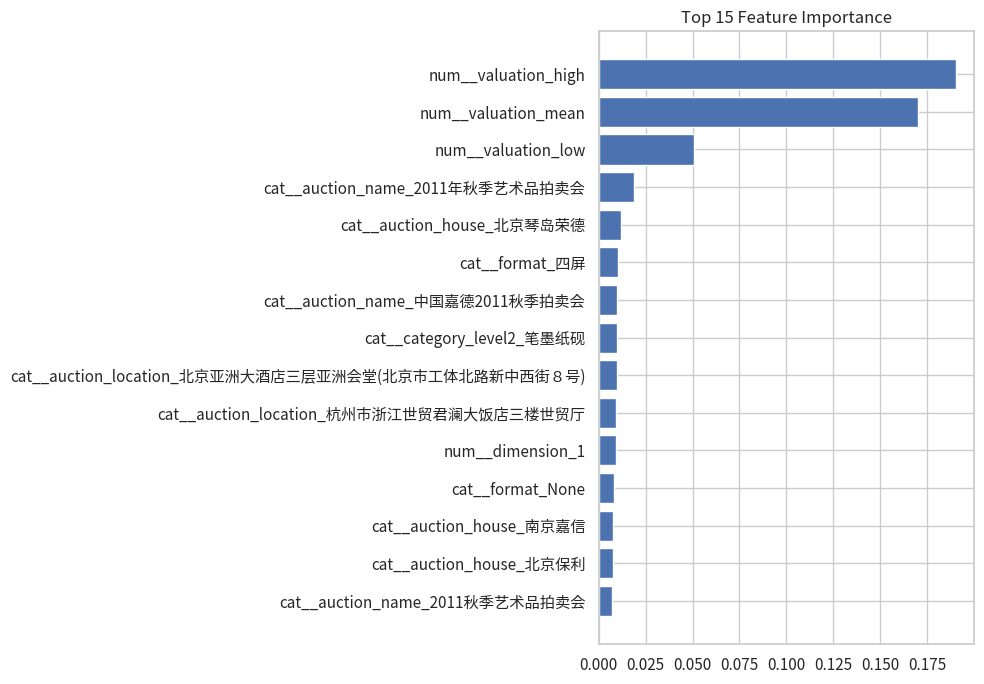

In [7]:
plot_df = result.feature_importance.head(15).sort_values('importance')
plt.figure(figsize=(10, 7))
plt.barh(plot_df['feature'], plot_df['importance'])
plt.title('Top 15 Feature Importance')
plt.tight_layout()
plt.show()

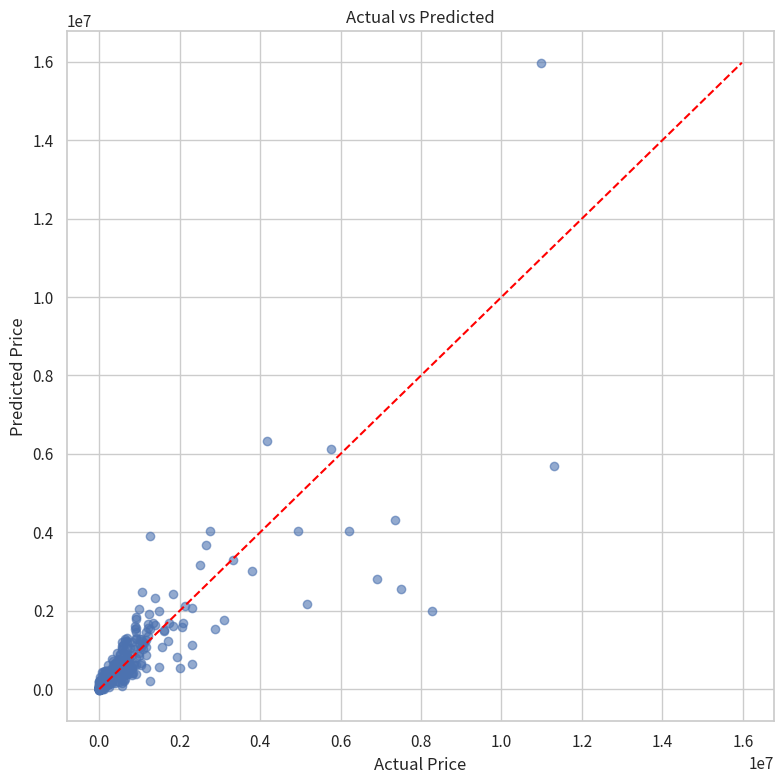

In [8]:
scatter_df = result.predictions.copy()
plt.figure(figsize=(8, 8))
plt.scatter(scatter_df['actual_price'], scatter_df['predicted_price'], alpha=0.6)
line_max = max(scatter_df['actual_price'].max(), scatter_df['predicted_price'].max())
plt.plot([0, line_max], [0, line_max], color='red', linestyle='--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')
plt.tight_layout()
plt.show()